# ***Telecom X - Análisis de evasión de clientes***

Este análisis busca identificar los factores que influyen en la evasión (Churn) de clientes en Telecom X.

## **1. Extracción de datos**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

datos = pd.read_json(url)

datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#**2. Transformación de datos**



In [3]:
cliente = pd.json_normalize(datos["customer"])
telefono = pd.json_normalize(datos["phone"])
internet = pd.json_normalize(datos["internet"])
cuenta = pd.json_normalize(datos["account"])

In [4]:
datos_limpios = pd.concat(
    [datos["customerID"], datos["Churn"], cliente, telefono, internet, cuenta],
    axis=1
)

datos_limpios.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#**3. Exploración del dataset**


In [5]:
datos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [15]:
datos_limpios.describe()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total
count,7267.000000,7267.000000,7267.000000,7256.000000
mean,0.162653,32.346498,64.720098,2280.634213
std,0.369074,24.571773,30.129572,2268.632997
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.425000,400.225000
50%,0.000000,29.000000,70.300000,1391.000000
75%,0.000000,55.000000,89.875000,3785.300000
max,1.000000,72.000000,118.750000,8684.800000


## **4. Limpieza y tratamiento de datos**

In [17]:
datos_limpios["Charges.Total"] = pd.to_numeric(datos_limpios["Charges.Total"], errors="coerce")


In [18]:
# Revisamos valores nulos
datos_limpios["Charges.Total"].isnull().sum()

np.int64(11)

## **5. Distribución de evasión (Churn)**

In [12]:
datos_limpios["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [22]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

/tmp/ipykernel_1339/380062777.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_1339/380062777.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(


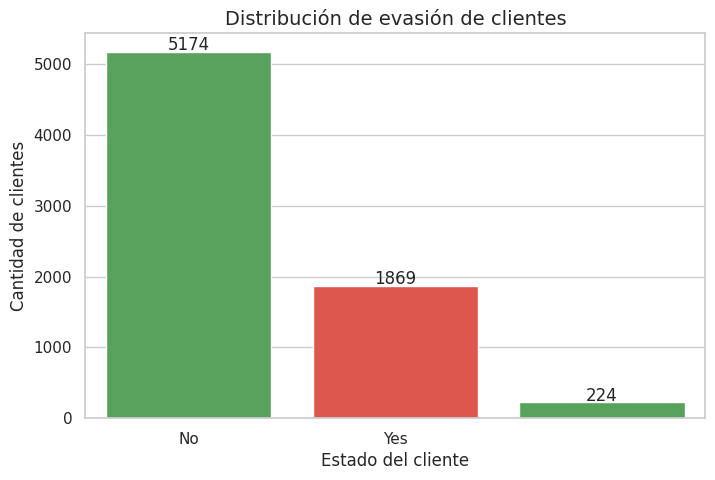

In [32]:
churn_counts = datos_limpios["Churn"].value_counts()

ax = sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values,
    palette=["#4CAF50", "#F44336"]
)

plt.title("Distribución de evasión de clientes", fontsize=14)
plt.xlabel("Estado del cliente")
plt.ylabel("Cantidad de clientes")

for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 20, str(v), ha="center")

plt.show()

## **6. Evasión por variables categóricas**

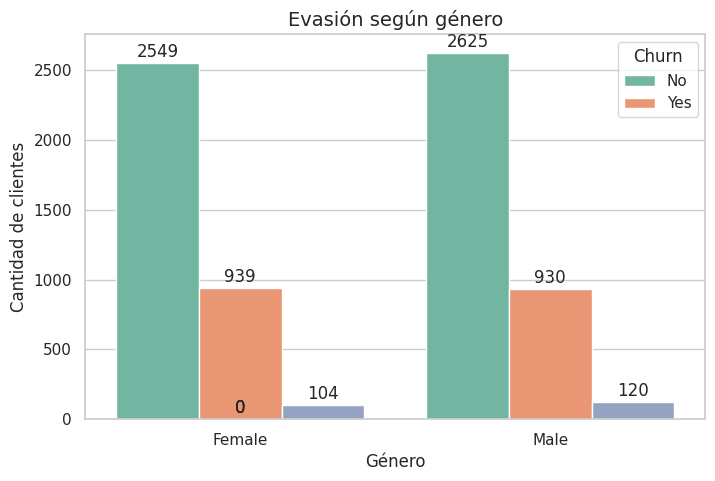

In [35]:
ax = sns.countplot(
    data=datos_limpios,
    x="gender",
    hue="Churn",
    palette="Set2"
)

plt.title("Evasión según género", fontsize=14)
plt.xlabel("Género")
plt.ylabel("Cantidad de clientes")

for p in ax.patches:
    ax.annotate(
        format(p.get_height(), ".0f"),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points"
    )

plt.show()

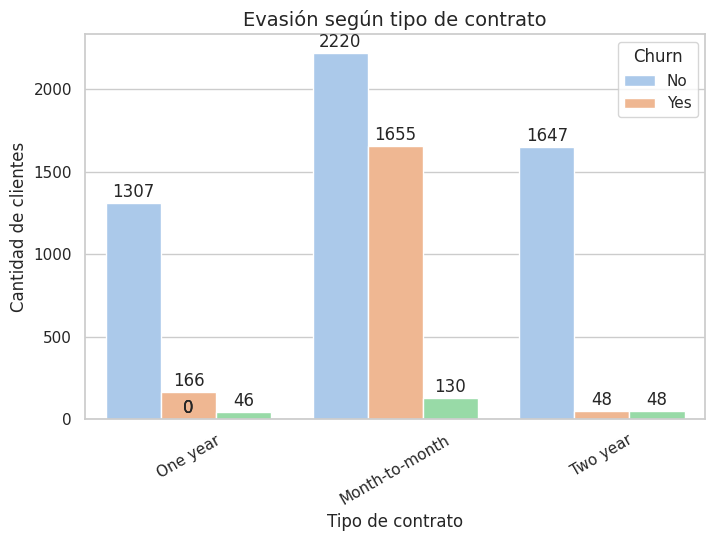

In [36]:
ax = sns.countplot(
    data=datos_limpios,
    x="Contract",
    hue="Churn",
    palette="pastel"
)

plt.title("Evasión según tipo de contrato", fontsize=14)
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")

plt.xticks(rotation=30)

for p in ax.patches:
    ax.annotate(
        format(p.get_height(), ".0f"),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points"
    )

plt.show()

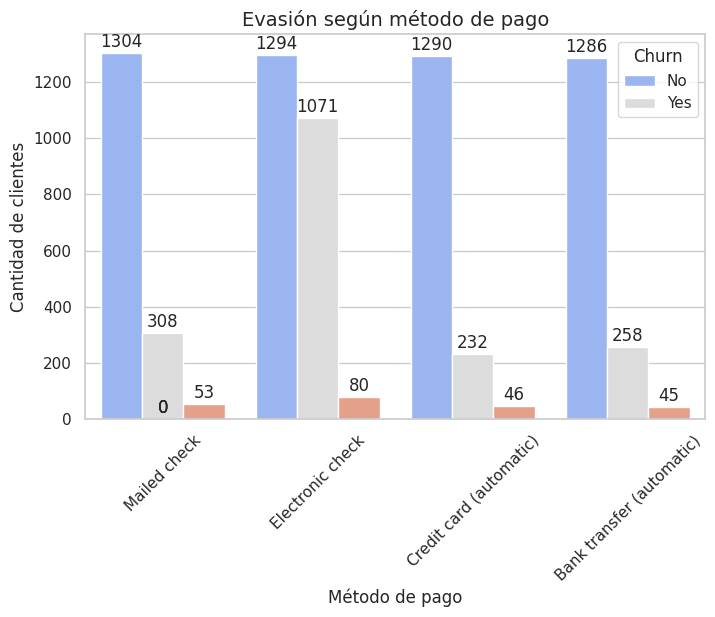

In [37]:
ax = sns.countplot(
    data=datos_limpios,
    x="PaymentMethod",
    hue="Churn",
    palette="coolwarm"
)

plt.title("Evasión según método de pago", fontsize=14)
plt.xlabel("Método de pago")
plt.ylabel("Cantidad de clientes")

plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(
        format(p.get_height(), ".0f"),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points"
    )

plt.show()

## **7. Evasión por variables numéricas**

/tmp/ipykernel_1339/825366491.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


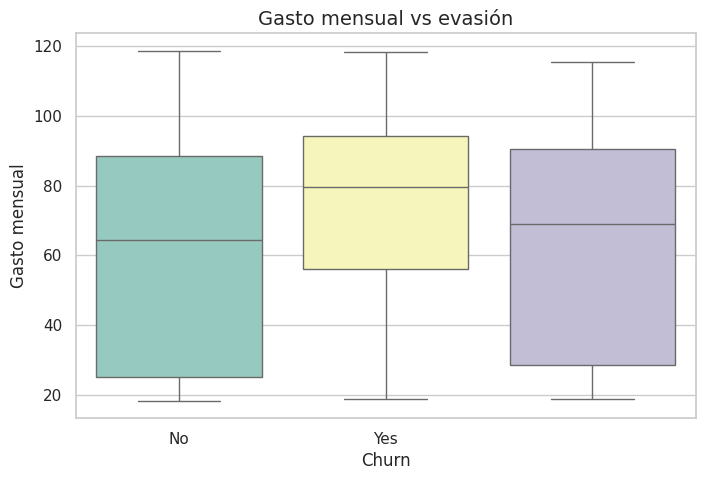

In [39]:
sns.boxplot(
    data=datos_limpios,
    x="Churn",
    y="Charges.Monthly",
    palette="Set3"
)

plt.title("Gasto mensual vs evasión", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Gasto mensual")

plt.show()

/tmp/ipykernel_1339/655358054.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


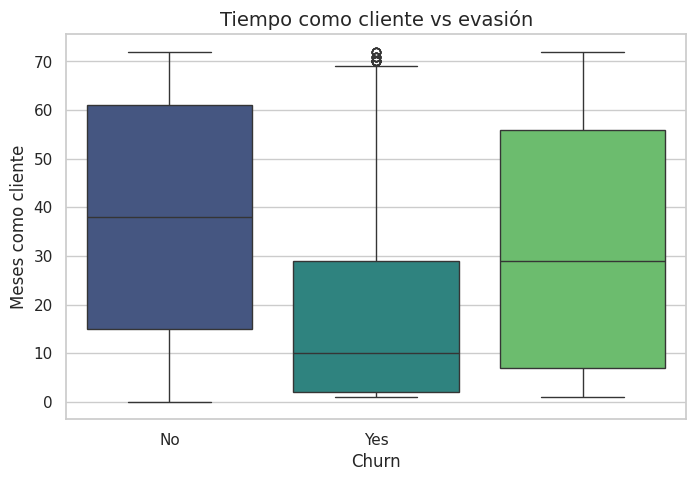

In [40]:
sns.boxplot(
    data=datos_limpios,
    x="Churn",
    y="tenure",
    palette="viridis"
)

plt.title("Tiempo como cliente vs evasión", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Meses como cliente")

plt.show()

## **8. Correlación entre variables**

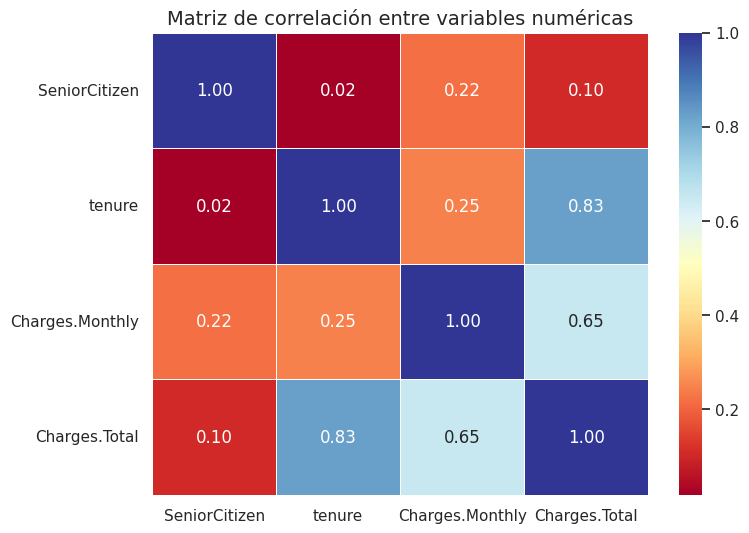

In [41]:
corr = datos_limpios.corr(numeric_only=True)
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlBu",
    fmt=".2f",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Matriz de correlación entre variables numéricas", fontsize=14)

plt.show()

## **9. Conclusiones**

El análisis exploratorio muestra que los clientes con contratos mensuales presentan mayor probabilidad de evasión.  
También se observa que los clientes con mayores cargos mensuales tienden a cancelar el servicio con mayor frecuencia.

## **10. Recomendaciones**

Telecom X podría incentivar contratos de mayor duración mediante promociones o beneficios.  
También se recomienda analizar la estructura de precios para mejorar la retención de clientes.